In [1]:
#Let's test the probabilistic programs generation!

import os
import re
import json
import sys
import torch
import requests
sys.path.insert(0, "DeGAS/src")

from optimization import optimize, compile2SOGA, compile2SOGA_text, produce_cfg, produce_cfg_text, smooth_cfg, start_SOGA, initialize_params

from PROGRAMS.likelihood import compute_likelihood

#generate some synthetic data matching the stats
import numpy as np
from param_extractor import extract_params
from mutation_prompt import build_mutation_prompt

import matplotlib.pyplot as plt

/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
import requests
import json
import re
import time

OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://140.105.52.180:11434")
OLLAMA_GENERATE_URL = f"{OLLAMA_BASE_URL}/api/generate"
OLLAMA_CHAT_URL = f"{OLLAMA_BASE_URL}/api/chat"
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "gpt-oss:20b")

PROGRAMS_SCHEMA = {
    "type": "object",
    "required": ["programs"],
    "properties": {
        "programs": {
            "type": "array",
            "items": {
                "type": "object",
                "required": ["id", "hypothesis", "structure", "program"],
                "properties": {
                    "id": {"type": "integer"},
                    "hypothesis": {"type": "string"},
                    "structure": {"type": "string"},
                    "program": {"type": "string"}
                }
            }
        }
    }
}

def _extract_response_text(resp_json: dict) -> str:
    """Get model text from common Ollama response shapes."""
    if not isinstance(resp_json, dict):
        return ""
    if isinstance(resp_json.get("response"), str):
        return resp_json["response"]
    message = resp_json.get("message")
    if isinstance(message, dict) and isinstance(message.get("content"), str):
        return message["content"]
    if isinstance(resp_json.get("content"), str):
        return resp_json["content"]
    return ""

def _extract_json(raw: str):
    """Parse direct JSON first, then recover JSON object/array embedded in text."""
    text = (raw or "").strip()
    if not text:
        raise ValueError("Empty model response")
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"(\{.*\}|\[.*\])", text, flags=re.DOTALL)
        if match:
            return json.loads(match.group(1))
        raise

def _normalize_programs_payload(obj):
    """Accept either {'programs': [...]} or [...] and normalize."""
    if isinstance(obj, list):
        return {"programs": obj}
    if isinstance(obj, dict) and "programs" in obj and isinstance(obj["programs"], list):
        return obj
    raise ValueError(f"Unexpected JSON shape: {type(obj)}")

def _post_ollama(payload: dict, use_chat: bool = True, request_timeout: int = 600, max_http_retries: int = 3) -> dict:
    """POST to Ollama with retry on transient timeout/connection errors."""
    url = OLLAMA_CHAT_URL if use_chat else OLLAMA_GENERATE_URL
    last_exc = None
    for attempt in range(max_http_retries + 1):
        try:
            response = requests.post(url, json=payload, timeout=request_timeout)
            response.raise_for_status()
            return response.json()
        except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectionError) as exc:
            last_exc = exc
            if attempt >= max_http_retries:
                break
            time.sleep(1.5 * (attempt + 1))
    raise last_exc

def call_ollama(
    user_message: str,
    system_prompt: str,
    model: str = OLLAMA_MODEL,
    temperature: float = 0.2,
    require_json: bool = True,
    max_retries: int = 1,
    use_chat: bool = True,
    request_timeout: int = 600,
    max_http_retries: int = 3,
):
    model = model.strip()
    # JSON tasks need a larger token budget; otherwise gpt-oss can stop before content is emitted.
    num_predict = 4000 if require_json else 1200

    if use_chat:
        payload = {
            "model": model,
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_message},
            ],
            "stream": False,
            "options": {
                "temperature": temperature,
                "num_predict": num_predict
            },
        }
    else:
        prompt = f"""{system_prompt}

User: {user_message}
Assistant:"""
        payload = {
            "model": model,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": temperature,
                "num_predict": num_predict
            },
        }

    if require_json:
        payload["format"] = PROGRAMS_SCHEMA

    try:
        resp_json = _post_ollama(
            payload,
            use_chat=use_chat,
            request_timeout=request_timeout,
            max_http_retries=max_http_retries,
        )
    except Exception as exc:
        return {
            "programs": [],
            "parse_error": f"Transport error: {exc}",
            "raw_response": "",
            "response_json": {},
        }

    raw = _extract_response_text(resp_json)

    if not require_json:
        return raw

    for attempt in range(max_retries + 1):
        try:
            parsed = _extract_json(raw)
            return _normalize_programs_payload(parsed)
        except Exception as exc:
            if attempt >= max_retries:
                return {
                    "programs": [],
                    "parse_error": str(exc),
                    "raw_response": raw,
                    "response_json": resp_json,
                }

            retry_user_message = (
                "Return ONLY valid JSON with this exact top-level shape:\n"
                "{\"programs\": [{\"id\": int, \"hypothesis\": str, \"structure\": str, \"program\": str}]}\n\n"
                f"Task:\n{user_message}"
            )

            if use_chat:
                retry_payload = {
                    "model": model,
                    "messages": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": retry_user_message},
                    ],
                    "stream": False,
                    "options": {"temperature": 0.0, "num_predict": num_predict},
                }
            else:
                retry_prompt = f"""{system_prompt}

User: {retry_user_message}
Assistant:"""
                retry_payload = {
                    "model": model,
                    "prompt": retry_prompt,
                    "stream": False,
                    "options": {"temperature": 0.0, "num_predict": num_predict},
                }

            try:
                resp_json = _post_ollama(
                    retry_payload,
                    use_chat=use_chat,
                    request_timeout=request_timeout,
                    max_http_retries=max_http_retries,
                )
                raw = _extract_response_text(resp_json)
            except Exception as retry_exc:
                return {
                    "programs": [],
                    "parse_error": f"Transport error on retry: {retry_exc}",
                    "raw_response": raw,
                    "response_json": resp_json,
                }

In [4]:
SYSTEM_PROMPT = """You are a helpful assistant."""
print(call_ollama("Hello, how are you?", model="gpt-oss:20b", require_json=False))

Hello! I’m doing great—thanks for asking. How can I help you today?


In [5]:
DEGAS_GRAMMAR = """
## DeGAS Language Reference

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PROGRAM STRUCTURE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Instructions must end with ;
    instr1;
    instr2;
    instr3;

Two kinds of instruction:
    assignment    var = expr;
    conditional   if condition { 
                    program
                  } else {
                    program
                  } end if;

Variables: only the variables of the dataset are available.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 NUMBERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Any decimal with at most 2 decimal places in [-100.00, 100.00].
    OK:    0.75    -3.14    50.00    -0.01    100.00
    NOT:   1/3     0.125    1e-2     .5

Positive numbers (weights, standard deviations): must be > 0.
    OK:    0.01    0.50    1.00    3.14    99.99

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DISTRIBUTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Gaussian mixture
   ─────────────────────────────────────────
   gm([pi_1, ..., pi_n], [mu_1, ..., mu_n], [sigma_1, ..., sigma_n])

   Constraints:
     • All three lists must have the same length  n ≥ 1
     • pi_i > 0  and  sum(pi) = 1.00   (weights)
     • sigma_i > 0                      (standard deviations)
     • mu_i  any number in [-100, 100]  (means)

   Examples:
     gm([1.00], [0.00], [1.00])                            ← 1-component (Gaussian)
     gm([0.60, 0.40], [2.00, -1.50], [0.50, 0.80])        ← 2-component
     gm([0.30, 0.50, 0.20], [4.00, 0.00, -3.00], [0.50, 1.00, 0.50])  ← 3-component

2. Uniform
   ─────────────────────────────────────────
   uniform([start, end], 2)

   Constraints:
     • start < end
     • Both in [-100.00, 100.00]
     • The literal  2  is always the third element — do not change it

   Examples:
     uniform([0.00, 1.00], 2)
     uniform([-5.00, 5.00], 2)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ASSIGNMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    var = expr;

expr must contain AT MOST ONE multiplication (*).
When a product has a number and a variable, the NUMBER MUST COME FIRST.
No division (/) is allowed. Only +, -, *.

Legal expression forms:

    atom                        a single value
    number * var                scaled variable    (number first)
    number * distribution       scaled sample      (number first)
    var * var                   product of two variables
    atom  +  atom               sum  (neither side is a product)
    atom  -  atom               difference
    number * var + atom       one product plus one atom
    number * var - atom
    atom + number * var
    atom - number * var
    number * dist + atom      same but with a distribution
    atom + number * dist

Where  atom  =  var | number | distribution

The key rule: a single assignment line may have at most one * .
If you need two products, introduce a temporary variable:

    INVALID:  a = 2.00*b + 3.00*c;
    VALID:    a = 2.00*b;  a = a + 3.00*c;

    INVALID:  a = 2.00*b*b;
    VALID:    a = b*b; a = 2.00*a;

    INVALID:  a = b*3.00;           (number must come first)
    VALID:    a = 3.00*b;

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CONDITIONALS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                  if condition { 
                    program
                  } else {
                    program
                  } end if;

Condition forms:
    var == number       var != number          (equality)
    lexpr  <  number    lexpr  <= number
    lexpr  >= number    lexpr  >  number       (comparison)

    lexpr = var

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 COMPLETE EXAMPLES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1 — Single Gaussian
a = gm([1.00], [3.50], [1.20]);

# 2 — Two-component mixture
a = gm([0.70, 0.30], [4.00, -2.00], [0.50, 1.00]);

# 3 — Mixture with linear transform (one product per line)
a = gm([0.60, 0.40], [2.00, -1.00], [0.50, 0.80]);
b = 2.00*a;
c = b + 0.50;

# 4 — Three-component heavy-tailed mixtur
a = gm([0.20, 0.60, 0.20], [0.00, 0.00, 0.00], [5.00, 1.00, 0.30]);

# 5 — Conditional latent structure
a = uniform([0.00, 1.00], 2);
if a > 0.50 {
  b = gm([1.00], [5.00], [0.80]);
} else {
  b = gm([1.00], [-2.00], [0.60]);
} end if;

# 6 — Hierarchical: scale a mixture by a latent factor
a = gm([0.50, 0.50], [1.00, -1.00], [0.50, 0.50]);
b = gm([1.00], [0.00], [0.20]);
c = a*b;

# 7 — Two products needing a temp variable (pattern to follow)
a = gm([1.00], [0.00], [1.00]);
b = 2.00*a;
b = b + 3.00*a;

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 WHAT NOT TO WRITE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
x a = Normal(0, 1);              → a = gm([1.00], [0.00], [1.00]);
x a = gm([0.5,0.5],[0,0],[1,1]); → a = gm([0.50, 0.50], [0.00, 0.00], [1.00, 1.00]);
x a = b/c;                       → division not allowed
x a = 2.00*b + 3.00*c;          → split: a = 2.00*b :: a = a + 3.00*c;
x a = b*3.00;                   → a = 3.00*b;
x a = 2.00*b*c;                 → split: a = b*c :: a = 2.00*a;
x uniform([0, 1]);               → uniform([0.00, 1.00], 2);
x weights: [0.33, 0.33, 0.34]   → use 2 decimals summing to 1: [0.34, 0.33, 0.33]
"""

SYSTEM_PROMPT = (
    "You are an expert in probabilistic programming and Bayesian modelling.\n"
    "You write programs exclusively in DeGAS, following the reference below.\n\n"
    + DEGAS_GRAMMAR
    + """
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 RULES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Numbers: exactly 2 decimal places, range [-100.00, 100.00]
• gm weights must sum to exactly 1.00
• At most one * per assignment line
• Coefficient always before variable in products
• No division
• Only variables a, b, c, d. Do NOT put underscores or other characters in variable names.
• Reply ONLY with a valid JSON object — no prose, no markdown fences
"""
)


In [6]:
def make_init_prompt(data_stats: dict, n_programs: int = 5) -> str:
    """
    User message for initial population generation.
 
    data_stats example:
        {"n": 340, "mean": 8.4, "std": 9.1, "min": 0.1, "max": 47.3,
         "skewness": 2.1, "kurtosis": 6.4, "sample": [0.3, 1.1, 8.2]}
    """
    stats_lines = "\n".join(f"  {k}: {v}" for k, v in data_stats.items())
 
    structure_targets = [
        "unimodal      — single gm component, match the data mean and std",
        "mixture2      — two-component gm, one per apparent subpopulation",
        "mixture3      — three-component gm for skewed or multi-modal data",
        "conditional   — uniform latent + if/else branching on its value",
        "hierarchical  — product of two distributions (use temp variable)",
    ]
    targets = "\n".join(
        f"  {i+1}. {t}" for i, t in enumerate(structure_targets[:n_programs])
    )
 
    return f"""Data summary:
{stats_lines}
 
Generate exactly {n_programs} DeGAS programs that are STRUCTURALLY DIVERSE and include all the variables of the dataset.
Aim for one program per structure type below:
{targets}
 
For each program:
  1. Write a one-sentence hypothesis about the data-generating process.
  2. Choose distribution families matching the data range and shape.
  3. Write valid DeGAS code — remember at most one * per line.
 
Return ONE JSON object with the exact shape below (no prose, no markdown):
{{
  "programs": [
    {{
      "id": 1,
      "hypothesis": "Data is unimodal and right-skewed.",
      "structure": "unimodal",
      "program": "a = gm([1.00], [8.00], [9.00]); b = gm([1.00], [8.00], [9.00]);"
    }}
  ]
}}
"""

In [7]:
def generate_if_dataset(data_size):
    data = []
    for _ in range(data_size):
        a = np.random.normal(1, 2)
        if a < 0:
            b = a * 3 + np.random.normal(0, 1)
        else:
            b = np.random.normal(8, 1)
        data.append([a, b])
    return data

data = generate_if_dataset(1000)

In [8]:
#stats = {"var_names": ['a', 'b'], "n": 200, "mean": [4.20, 5.10], "std": [3.10, 2.80], "skewness": [1.80, -1.20],
#            "min": [0.10, 1.20], "max": [18.50, 25.30]}

#generate stats from data
stats = {
    "var_names": ['a', 'b'],
    "n": len(data),
    "mean": np.mean(data, axis=0).tolist(),
    "std": np.std(data, axis=0).tolist(),
    "skewness": (np.mean((data - np.mean(data, axis=0))**3, axis=0) / (np.std(data, axis=0)**3)).tolist(),
    "kurtosis": (np.mean((data - np.mean(data, axis=0))**4, axis=0) / (np.std(data, axis=0)**4)).tolist(),
    "min": np.min(data, axis=0).tolist(),
    "max": np.max(data, axis=0).tolist(),
}
prompt = make_init_prompt(stats, n_programs=5)
print(prompt)


Data summary:
  var_names: ['a', 'b']
  n: 1000
  mean: [1.006681786412194, 4.420796194990558]
  std: [1.9853533378131987, 5.808287378916302]
  skewness: [-0.009153153880054962, -1.1576427552161228]
  kurtosis: [3.1949965863115346, 3.0853603509358445]
  min: [-5.462298008004948, -16.34590401874548]
  max: [8.150403571475358, 11.386596954133056]

Generate exactly 5 DeGAS programs that are STRUCTURALLY DIVERSE and include all the variables of the dataset.
Aim for one program per structure type below:
  1. unimodal      — single gm component, match the data mean and std
  2. mixture2      — two-component gm, one per apparent subpopulation
  3. mixture3      — three-component gm for skewed or multi-modal data
  4. conditional   — uniform latent + if/else branching on its value
  5. hierarchical  — product of two distributions (use temp variable)

For each program:
  1. Write a one-sentence hypothesis about the data-generating process.
  2. Choose distribution families matching the data ran

In [15]:
# initialization
result = call_ollama(
    prompt,
    model="gpt-oss:20b",
    temperature=0.2,
    require_json=True,
    max_retries=1,
    use_chat=True,
    request_timeout=600,
    max_http_retries=3,
 )
candidates = result
print(candidates)

{'programs': [{'id': 1, 'hypothesis': 'Data is generated from a single Gaussian distribution.', 'structure': 'unimodal', 'program': 'a = gm([1.00], [1.01], [1.99]); b = gm([1.00], [4.42], [5.81]);'}, {'id': 2, 'hypothesis': 'Data arises from two overlapping subpopulations.', 'structure': 'mixture2', 'program': 'a = gm([0.50,0.50], [0.00,2.00], [1.50,1.50]); b = gm([0.50,0.50], [3.00,5.84], [5.50,5.50]);'}, {'id': 3, 'hypothesis': 'Data exhibits three distinct subpopulations, indicating multimodality.', 'structure': 'mixture3', 'program': 'a = gm([0.30,0.40,0.30], [-1.00,1.00,3.00], [1.50,1.50,1.50]); b = gm([0.30,0.40,0.30], [2.00,4.40,7.00], [5.50,5.50,5.50]);'}, {'id': 4, 'hypothesis': 'Data generation depends on a latent uniform variable that selects between two regimes.', 'structure': 'conditional', 'program': 'c = uniform([0.00,1.00], 2); if c > 0.50 { a = gm([1.00], [1.00], [1.00]); b = gm([1.00], [4.00], [6.00]); } else { a = gm([1.00], [-1.00], [2.00]); b = gm([1.00], [6.00], [

In [16]:
for prog in candidates['programs']:
    print(f"\nProgram ID: {prog['id']}")
    print(f"Hypothesis: {prog['hypothesis']}")
    print(f"Structure: {prog['structure']}")
    print(f"DeGAS code:\n{prog['program']}")


Program ID: 1
Hypothesis: Data is generated from a single Gaussian distribution.
Structure: unimodal
DeGAS code:
a = gm([1.00], [1.01], [1.99]); b = gm([1.00], [4.42], [5.81]);

Program ID: 2
Hypothesis: Data arises from two overlapping subpopulations.
Structure: mixture2
DeGAS code:
a = gm([0.50,0.50], [0.00,2.00], [1.50,1.50]); b = gm([0.50,0.50], [3.00,5.84], [5.50,5.50]);

Program ID: 3
Hypothesis: Data exhibits three distinct subpopulations, indicating multimodality.
Structure: mixture3
DeGAS code:
a = gm([0.30,0.40,0.30], [-1.00,1.00,3.00], [1.50,1.50,1.50]); b = gm([0.30,0.40,0.30], [2.00,4.40,7.00], [5.50,5.50,5.50]);

Program ID: 4
Hypothesis: Data generation depends on a latent uniform variable that selects between two regimes.
Structure: conditional
DeGAS code:
c = uniform([0.00,1.00], 2); if c > 0.50 { a = gm([1.00], [1.00], [1.00]); b = gm([1.00], [4.00], [6.00]); } else { a = gm([1.00], [-1.00], [2.00]); b = gm([1.00], [6.00], [4.00]); } end if;

Program ID: 5
Hypothesis

In [17]:
for prog in candidates['programs']:
    #print(f"\nCompiling Program ID: {prog['program']}...")
    try:
        compiledFile = compile2SOGA_text(prog['program'])
        cfg = produce_cfg_text(compiledFile)
        smooth_cfg(cfg)
    
        # No free parameters — just evaluate the output distribution
        output_dist = start_SOGA(cfg, params_dict={})
        likelihood = compute_likelihood(output_dist, stats['var_names'], data)
        print(f"Program ID {prog['id']} likelihood: {likelihood:.4f}")

        
    except Exception as e:
        print(f"Error compiling program ID {prog['id']}: {e}")

Program ID 1 likelihood: -5.2830
Program ID 2 likelihood: -5.2984
Program ID 3 likelihood: -5.2977
Program ID 4 likelihood: -5.8982
Program ID 5 likelihood: -8.0020


In [18]:
for prog in candidates['programs']:
    print(f"\nExtracting parameters from Program ID: {prog['id']}...")
    try:
        # add to candidates the dict of parameters with their initial values and the rewritten program with parameters instead of literals
        rewritten, params_dict = extract_params(prog['program'])
        prog['params'] = params_dict
        prog['rewritten'] = rewritten
        print(f"Extracted parameters: {params_dict}")
    except Exception as e:
        print(f"Error extracting parameters from program ID {prog['id']}: {e}")


Extracting parameters from Program ID: 1...
Extracted parameters: {'mu1': 1.01, 'sigma1': 1.99, 'mu2': 4.42, 'sigma2': 5.81}

Extracting parameters from Program ID: 2...
Extracted parameters: {'mu1': 0.0, 'mu2': 2.0, 'sigma1': 1.5, 'sigma2': 1.5, 'mu3': 3.0, 'mu4': 5.84, 'sigma3': 5.5, 'sigma4': 5.5}

Extracting parameters from Program ID: 3...
Extracted parameters: {'mu1': -1.0, 'mu2': 1.0, 'mu3': 3.0, 'sigma1': 1.5, 'sigma2': 1.5, 'sigma3': 1.5, 'mu4': 2.0, 'mu5': 4.4, 'mu6': 7.0, 'sigma4': 5.5, 'sigma5': 5.5, 'sigma6': 5.5}

Extracting parameters from Program ID: 4...
Extracted parameters: {'mu1': 1.0, 'sigma1': 1.0, 'mu2': 4.0, 'sigma2': 6.0, 'mu3': -1.0, 'sigma3': 2.0, 'mu4': 6.0, 'sigma4': 4.0}

Extracting parameters from Program ID: 5...
Extracted parameters: {'mu1': 1.0, 'mu2': -1.0, 'sigma1': 1.0, 'sigma2': 1.0, 'mu3': 4.0, 'mu4': 6.0, 'sigma3': 2.0, 'sigma4': 2.0}


In [19]:
# Now let's do the gradient step 
#data = torch.tensor(data, dtype=torch.float64)
for prog in candidates['programs']:
    print(f"\nOptimizing Program ID: {prog['id']}...")
    try:
        compiledFile = compile2SOGA_text(prog['rewritten'])
        cfg = produce_cfg_text(compiledFile)
        smooth_cfg(cfg)
    
        # Initialize parameters
        params_dict = initialize_params(prog['params'])
        print(f"Initialized parameters: {params_dict}")
        
        # Define loss function for optimization
        loss = lambda output_dist : -compute_likelihood(output_dist, stats['var_names'], data)
        loss_list, time, number_of_iterations = optimize(cfg, params_dict, loss, n_steps=50, lr=0.01, print_progress=False)
        print(f"Program ID {prog['id']} optimization completed. Initial loss: {loss_list[0]:.4f}, Final loss: {loss_list[-1]:.4f}")
        prog['optimized_params'] = params_dict
        prog['initial_loss'] = loss_list[0]
        prog['final_loss'] = loss_list[-1]

    except Exception as e:
        print(f"Error optimizing program ID {prog['id']}: {e}")
        continue



Optimizing Program ID: 1...
Initialized parameters: {'mu1': tensor(1.0100, requires_grad=True), 'sigma1': tensor(1.9900, requires_grad=True), 'mu2': tensor(4.4200, requires_grad=True), 'sigma2': tensor(5.8100, requires_grad=True)}
Program ID 1 optimization completed. Initial loss: 5.2830, Final loss: 5.2830

Optimizing Program ID: 2...
Initialized parameters: {'mu1': tensor(0., requires_grad=True), 'mu2': tensor(2., requires_grad=True), 'sigma1': tensor(1.5000, requires_grad=True), 'sigma2': tensor(1.5000, requires_grad=True), 'mu3': tensor(3., requires_grad=True), 'mu4': tensor(5.8400, requires_grad=True), 'sigma3': tensor(5.5000, requires_grad=True), 'sigma4': tensor(5.5000, requires_grad=True)}
Program ID 2 optimization completed. Initial loss: 5.2984, Final loss: 5.2504

Optimizing Program ID: 3...
Initialized parameters: {'mu1': tensor(-1., requires_grad=True), 'mu2': tensor(1., requires_grad=True), 'mu3': tensor(3., requires_grad=True), 'sigma1': tensor(1.5000, requires_grad=Tru

In [20]:
new_programs = call_ollama(
    build_mutation_prompt(candidates['programs'], n_mutations=5, iteration=1, grammar=DEGAS_GRAMMAR),
    model="gpt-oss:20b",
    temperature=0.2,
    require_json=True,
    max_retries=1,
    use_chat=True,
    request_timeout=600,
    max_http_retries=3,
 )
print(new_programs)

/home/rdoz/PhD/LLM-guided_PP_synthesis/mutation_prompt.py:85: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  rel_move = abs(float(opt_val) - float(init_val)) / (abs(float(init_val)) + 1e-6)


{'programs': [{'id': 6, 'hypothesis': 'Data arises from two overlapping subpopulations, with the second subpopulation having three modes.', 'structure': 'split', 'program': 'a = gm([0.50,0.50], [0.00,2.00], [1.50,1.50]); b = gm([0.30,0.35,0.35], [3.00,5.00,6.50], [5.50,5.00,4.50]);'}, {'id': 7, 'hypothesis': 'Data generated from a single mixture with six modes.', 'structure': 'merge', 'program': 'a = gm([0.15,0.20,0.15,0.15,0.20,0.15], [-1.00,1.00,3.00,2.00,4.40,7.00], [1.50,1.50,1.50,5.50,5.50,5.50]);'}, {'id': 8, 'hypothesis': 'Data arises from two overlapping Gaussian subpopulations.', 'structure': 'mixture2', 'program': 'a = gm([0.50,0.50], [1.00,4.42], [1.99,5.81]); b = a;'}, {'id': 9, 'hypothesis': 'Data generated by a latent uniform variable selecting between two regimes, each regime modeled by a mixture of two Gaussians.', 'structure': 'hierarchical_split', 'program': 'c = uniform([0.00,1.00], 2); if c > 0.50 { a = gm([0.50,0.50], [0.80,1.20], [0.80,0.80]); b = gm([0.50,0.50], 

In [21]:
for prog in new_programs['programs']:
    print(f"\nProgram ID: {prog['id']}")
    print(f"Hypothesis: {prog['hypothesis']}")
    print(f"Structure: {prog['structure']}")
    print(f"DeGAS code:\n{prog['program']}")


Program ID: 6
Hypothesis: Data arises from two overlapping subpopulations, with the second subpopulation having three modes.
Structure: split
DeGAS code:
a = gm([0.50,0.50], [0.00,2.00], [1.50,1.50]); b = gm([0.30,0.35,0.35], [3.00,5.00,6.50], [5.50,5.00,4.50]);

Program ID: 7
Hypothesis: Data generated from a single mixture with six modes.
Structure: merge
DeGAS code:
a = gm([0.15,0.20,0.15,0.15,0.20,0.15], [-1.00,1.00,3.00,2.00,4.40,7.00], [1.50,1.50,1.50,5.50,5.50,5.50]);

Program ID: 8
Hypothesis: Data arises from two overlapping Gaussian subpopulations.
Structure: mixture2
DeGAS code:
a = gm([0.50,0.50], [1.00,4.42], [1.99,5.81]); b = a;

Program ID: 9
Hypothesis: Data generated by a latent uniform variable selecting between two regimes, each regime modeled by a mixture of two Gaussians.
Structure: hierarchical_split
DeGAS code:
c = uniform([0.00,1.00], 2); if c > 0.50 { a = gm([0.50,0.50], [0.80,1.20], [0.80,0.80]); b = gm([0.50,0.50], [3.00,5.00], [6.00,6.00]); } else { a = gm(

In [22]:
for prog in new_programs['programs']:
    #print(f"\nCompiling Program ID: {prog['program']}...")
    try:
        #print(prog['program'])
        compiledFile = compile2SOGA_text(prog['program'])
        cfg = produce_cfg_text(compiledFile)
        smooth_cfg(cfg)
    
        # No free parameters — just evaluate the output distribution
        output_dist = start_SOGA(cfg, params_dict={})
        likelihood = compute_likelihood(output_dist, stats['var_names'], data)
        print(f"Program ID {prog['id']} likelihood: {likelihood:.4f}")

        
    except Exception as e:
        print(f"Error compiling program ID {prog['id']}: {e}")
        continue

Program ID 6 likelihood: -5.2807
Program ID 7 likelihood: -inf
Error compiling program ID 8: Expected parameter covariance_matrix (Tensor of shape (2, 2)) of distribution MultivariateNormal(loc: torch.Size([2]), covariance_matrix: torch.Size([2, 2])) to satisfy the constraint PositiveDefinite(), but found invalid values:
tensor([[33.7561, 33.7561],
        [33.7561, 33.7561]])
Program ID 9 likelihood: -5.9685
Program ID 10 likelihood: -8.2326


Program ID 1 optimization completed. Initial loss: 5.2830, Final loss: 5.2830
Program ID 2 optimization completed. Initial loss: 5.7247, Final loss: 5.4532
Program ID 3 optimization completed. Initial loss: 5.4761, Final loss: 5.3531
Program ID 4 optimization completed. Initial loss: 5.3556, Final loss: 5.2910
Program ID 5 optimization completed. Initial loss: 5.2865, Final loss: 5.2830

--- Iteration 1 ---
Best candidate after iteration 1: Program ID 1, Final Loss: 5.2830
Selected candidates for next iteration: [1, 5, 4, 3, 2]

--- Iteration 2 ---
Program ID 11 optimization completed. Initial loss: 5.7866, Final loss: 5.2662
Error in program ID 12: Expected parameter loc (Tensor of shape (2,)) of distribution MultivariateNormal(loc: torch.Size([2]), covariance_matrix: torch.Size([2, 2])) to satisfy the constraint IndependentConstraint(Real(), 1), but found invalid values:
tensor([0.5586,    nan], grad_fn=<ExpandBackward0>)
Error in program ID 13: Expected parameter loc (Tensor of shap

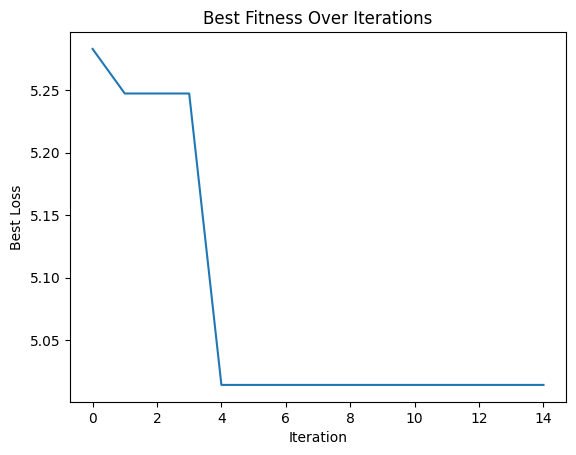

In [ ]:
# Create the pipeline
n_steps = 15

# First generation
result = call_ollama(prompt, model="gpt-oss:20b", temperature=0.2, require_json=True, max_retries=1, use_chat=True)
candidates = result["programs"]

# extract parameters and optimize each program
for prog in candidates:
    #print(f"\nExtracting parameters from Program ID: {prog['id']}...")
    try:
        # add to candidates the dict of parameters with their initial values and the rewritten program with parameters instead of literals
        rewritten, params_dict = extract_params(prog['program'])
        prog['params'] = params_dict
        prog['rewritten'] = rewritten
        #print(f"Extracted parameters: {params_dict}")
        compiledFile = compile2SOGA_text(prog['rewritten'])
        cfg = produce_cfg_text(compiledFile)
        smooth_cfg(cfg)
    
        # Initialize parameters
        params_dict = initialize_params(prog['params'])
        #print(f"Initialized parameters: {params_dict}")
        
        # Define loss function for optimization
        loss = lambda output_dist : -compute_likelihood(output_dist, stats['var_names'], data)
        loss_list, time, number_of_iterations = optimize(cfg, params_dict, loss, n_steps=50, lr=0.01, print_progress=False)
        print(f"Program ID {prog['id']} optimization completed. Initial loss: {loss_list[0]:.4f}, Final loss: {loss_list[-1]:.4f}")
        prog['optimized_params'] = params_dict
        prog['initial_loss'] = loss_list[0]
        prog['final_loss'] = loss_list[-1]
    except Exception as e:
        print(f"Error extracting parameters from program ID {prog['id']}: {e}")

best_fitness = []
#best_fitness.append(np.min([prog['final_loss'] for prog in candidates]))

for i in range(n_steps):
    print(f"\n--- Iteration {i+1} ---")
    new_programs = call_ollama(build_mutation_prompt(candidates, n_mutations=5, iteration=i+1, grammar=DEGAS_GRAMMAR), model="gpt-oss:20b", temperature=0.6, require_json=True, max_retries=1, use_chat=True)
    new_candidates = new_programs['programs']
    #extract parameters and optimize each new program
    for prog in new_candidates:
        #print(f"\nExtracting parameters from Program ID: {prog['id']}...")
        try:
            # add to candidates the dict of parameters with their initial values and the rewritten program with parameters instead of literals
            rewritten, params_dict = extract_params(prog['program'])
            prog['params'] = params_dict
            prog['rewritten'] = rewritten
            #print(f"Extracted parameters: {params_dict}")
            compiledFile = compile2SOGA_text(prog['rewritten'])
            cfg = produce_cfg_text(compiledFile)
            smooth_cfg(cfg)
        
            # Initialize parameters
            params_dict = initialize_params(prog['params'])
            #print(f"Initialized parameters: {params_dict}")
            
            # Define loss function for optimization
            loss = lambda output_dist : -compute_likelihood(output_dist, stats['var_names'], data)
            loss_list, time, number_of_iterations = optimize(cfg, params_dict, loss, n_steps=200, lr=0.01, print_progress=False)
            print(f"Program ID {prog['id']} optimization completed. Initial loss: {loss_list[0]:.4f}, Final loss: {loss_list[-1]:.4f}")
            prog['optimized_params'] = params_dict
            prog['initial_loss'] = loss_list[0]
            prog['final_loss'] = loss_list[-1]

        except Exception as e:
            print(f"Error in program ID {prog['id']}: {e}")
            prog['errors'] = str(e)
            prog['final_loss'] = float('inf')


    #choose the best 5 programs between new_candidates and candidates based on final_loss and keep them for the next iteration
    all_candidates = candidates + new_candidates
    all_candidates = [prog for prog in all_candidates if 'final_loss' in prog]
    all_candidates.sort(key=lambda x: x['final_loss'])
    candidates = all_candidates[:5]
    if not candidates:
        print(f"No valid candidates after iteration {i+1}; stopping early.")
        break

    best_candidate = candidates[0]
    print(f"Best candidate after iteration {i+1}: Program ID {best_candidate['id']}, Final Loss: {best_candidate['final_loss']:.4f}")
    best_fitness.append(best_candidate['final_loss'])
    print(f"Selected candidates for next iteration: {[prog['id'] for prog in candidates]}")

print("\n--- Final Selected Programs ---")
for prog in candidates:
    print(f"Program ID: {prog['id']}, Final Loss: {prog['final_loss']:.4f}")
    print(f"Hypothesis: {prog['hypothesis']}")
    print(f"Structure: {prog['structure']}")
    print(f"DeGAS code:\n{prog['program']}\n")  

if best_fitness:
    plt.plot(best_fitness)
    plt.title("Best Fitness Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Best Loss")
    plt.show()
else:
    print("No fitness values to plot.")